In [1]:
# import default modules
import numpy as np
from scipy import interpolate
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d, Axes3D 
from matplotlib import cm
import sys
import os
from scipy.ndimage import gaussian_filter1d
import shutil
import subprocess
from bluemath_tk.datamining.lhs import LHS
from bluemath_tk.datamining.mda import MDA

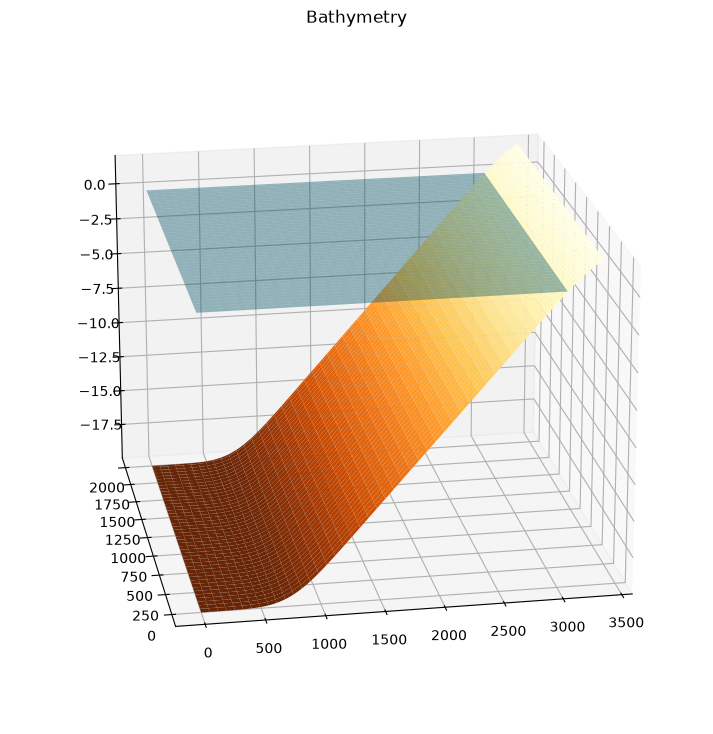

Shoreface starts at X = 750.0m
Transition to Slope 2 at X = 2441.77m
Shoreline (Z=0) at approx X = 3041.77m


In [2]:
# generate bathymetry
z0 = 20.0                     # initial depth (m)
theta_1 = .5                  # slope 1 (degrees)
theta_2 = .5                  # slope 2 (degrees)
x_flat_len = 750.0            # flat area before shore face (m)
dx = 5.0                      # grid spacing (m)
length_y = 2000.0             # beach/domain length (m) if boundary conditions are cyclic this must be a multiple of the wavelength
sigma_smooth = 40             # smoothing factor
w_szone = 600.0               # surfzone width (m)
w_beach = 300.0               # beach width (m)

tan1 = np.tan(np.deg2rad(theta_1))
tan2 = np.tan(np.deg2rad(theta_2))
z_trans_elevation = -(w_szone * tan2)
L1_width = (z_trans_elevation - (-z0)) / tan1
x_total = x_flat_len + L1_width + w_szone + w_beach
x_final = np.arange(0, x_total + dx, dx)
y_final = np.arange(0, length_y + dx, dx)

def calculate_elevation(x_val):
    xr = x_val - x_flat_len
    if xr < 0:
        return -z0
    elif 0 <= xr < L1_width:
        return tan1 * xr - z0
    else:
        z_at_end_l1 = tan1 * L1_width - z0
        return z_at_end_l1 + tan2 * (xr - L1_width)

f_x = np.array([calculate_elevation(x) for x in x_final])
elevation_1d = gaussian_filter1d(f_x, sigma=sigma_smooth, mode='nearest')

X, Y = np.meshgrid(x_final, y_final)
elevation_2d = np.tile(elevation_1d, (len(y_final), 1))
bathy_2d = -elevation_2d

# plotting
water_mask = np.ma.masked_where(elevation_2d > 0, np.zeros_like(elevation_2d))
fig = plt.figure(figsize=(14, 9))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, elevation_2d, cmap='YlOrBr_r', edgecolor='none', alpha=1)
water = ax.plot_surface(X, Y, water_mask, color='#006884', alpha=0.4, linewidth=0)
ax.set_title(f'Bathymetry')
ax.set_zlim(np.min(elevation_2d), 2.0)
ax.view_init(elev=20, azim=-100)
plt.show()

np.savetxt('bathy.dep', bathy_2d, fmt='%.4f')
np.savetxt('x.grd', X, fmt='%.4f')
np.savetxt('y.grd', Y, fmt='%.4f')

print(f"Shoreface starts at X = {x_flat_len}m")
print(f"Transition to Slope 2 at X = {x_flat_len + L1_width:.2f}m")
print(f"Shoreline (Z=0) at approx X = {x_flat_len + L1_width + w_szone:.2f}m")

In [3]:
nx = X.shape[1] - 1
ny = X.shape[0] - 1

params = f"""
! --- Grid Parameters ---
nx           = {nx}
ny           = {ny}
coord        = cartesian   
vardx        = 1
xfile        = x.grd
yfile        = y.grd
depfile      = bathy.dep
posdwn       = 1    
posfree      = 1 
split        = 1
outputformat = netcdf

! --- Wave & Boundary Conditions ---
nonh         = 1
cyclic       = 1
wavemodel    = nonh
dirnorm      = 0
thetamin     = -90          
thetamax     = 90           
dtheta       = 10           
wbctype      = parametric        
bcfile       = jonswap.txt  
front        = nonh_1d     
back         = wall       
lateralwave  = cyclic
reuse        = 0
CFL          = 0.5 
nhq3d        = 1

! --- Sediment Parameters (Uniform) ---
morphology   = 1
sedtrans     = 1
ngd          = 1            
D50          = 0.0002       
D90          = 0.0003
por          = 0.4
rhos         = 2650.0     

! --- Model Time ---
tstart       = 0 
tstop        = 3600                            
tintm        = 600          
tintg        = 2           

nglobalvar   = 4 
Svsg
Susg
Svbg
Subg
"""

with open("params.txt", "w") as f:
    f.write(params)

In [4]:
# Safe to re-run: existing case folders/outputs are no longer deleted.
# Keep SEED, n_lhs and variable_ranges unchanged -> same LHS pool, and MDA picks
# centers greedily, so the first 200 of the 1000 are exactly the 200 already run.
SEED = 42

variable_ranges = {
    "hm0": (0.5, 3.0),
    "s0": (0.01, 0.03),
    "ang": (200.0, 340.0),
}

n_lhs = 2000   
n_subset = 1000 

lhs = LHS(num_dimensions=len(variable_ranges), seed=SEED)
lhs_data = lhs.generate(
    dimensions_names=list(variable_ranges.keys()),
    lower_bounds=[v[0] for v in variable_ranges.values()],
    upper_bounds=[v[1] for v in variable_ranges.values()],
    num_samples=n_lhs,
)
lhs_data.head()

,hm0,s0,ang
0,2.475283,0.010606,289.609898
1,0.927878,0.029559,277.421706
2,2.245299,0.021562,267.681032
3,2.055687,0.023436,285.545126
4,0.574195,0.014632,279.418961


In [5]:
mda = MDA(num_centers=n_subset)
mda.fit_predict(
    data=lhs_data[["hm0", "s0", "ang"]],
    directional_variables=[],
)
train_idx = mda.centroid_real_indices
# NOTE: fit_predict's 2nd output is the nearest centroid for EVERY LHS point (n_lhs rows,
# mostly duplicates), not the selected cases. Take the selected cases directly, in MDA
# selection order (same values -> same folder names as before).
subset_data = lhs_data.iloc[train_idx].reset_index(drop=True)
assert len(subset_data) == n_subset
print(f"Selected {len(train_idx)} training cases out of {len(lhs_data)}")
subset_data.head()

Selected 1000 training cases out of 2000


,hm0,s0,ang
0,2.425212,0.023510,339.731049
1,1.543064,0.017666,200.026179
2,2.452996,0.020316,269.903807
3,2.267820,0.018080,234.931454
4,1.311406,0.019764,304.840525


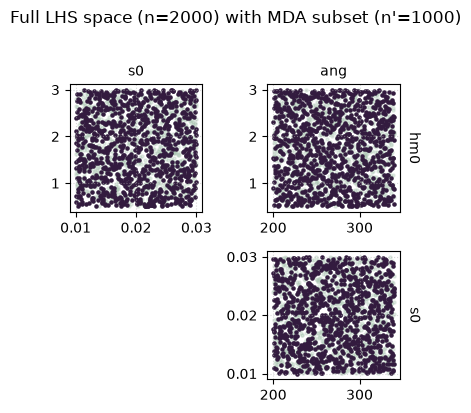

In [6]:
variables = list(variable_ranges.keys())
n_vars = len(variables)
fig, axs = plt.subplots(n_vars - 1, n_vars - 1, figsize=(2 * (n_vars - 1), 2 * (n_vars - 1)))
for row in range(n_vars - 1):
    for col in range(n_vars - 1):
        ax = axs[row, col]
        if col < row:
            ax.axis("off")
            continue
        x_var = variables[col + 1]
        y_var = variables[row]
        ax.scatter(lhs_data[x_var], lhs_data[y_var], s=5, alpha=0.3, c="#acc7b4")
        ax.scatter(subset_data[x_var], subset_data[y_var], s=5, c="#331b3f")
        ax.grid(True, linestyle=":", alpha=0.5)
        if row == 0:
            ax.set_title(x_var, fontsize=10)
        if col == n_vars - 2:
            ax.yaxis.set_label_position("right")
            ax.set_ylabel(y_var, rotation=270, labelpad=15)
plt.suptitle(f"Full LHS space (n={n_lhs}) with MDA subset (n'={n_subset})", y=1.02)
plt.tight_layout()
plt.show()

In [7]:
base_dir = "xbeach_cases"
os.makedirs(base_dir, exist_ok=True)   # never wipe: finished cases and their outputs are kept

case_dirs = []
n_new = n_existing = 0
for _, row in subset_data.iterrows():
    hm0 = row["hm0"]
    s0 = row["s0"]
    ang = row["ang"]
    tp = np.sqrt(hm0 / (1.56 * s0))  # steepness -> period conversion

    folder_name = f"run_hm0_{hm0:.2f}_s0_{s0:.4f}_ang_{ang:.2f}"
    folder_path = os.path.join(base_dir, folder_name)
    case_dirs.append(folder_path)

    jonswap_path = os.path.join(folder_path, "jonswap.txt")
    if os.path.exists(jonswap_path):   # case already set up (maybe already run) -> leave it alone
        n_existing += 1
        continue

    os.makedirs(folder_path, exist_ok=True)
    wave_input = f"""Hm0 = {hm0:.2f}
Tp = {tp:.2f}
mainang = {ang:.2f}
gammajsp = 20.0
s = 16.0
fnyq = 0.3
eps = 0.01         
dryslp = 1.0       
"""
    with open(jonswap_path, "w") as f:
        f.write(wave_input)
    n_new += 1

assert len(set(case_dirs)) == len(case_dirs), "two cases round to the same folder name"

# case_list.txt is in MDA order: any first-N lines are themselves a well-spread design,
# so partial results are still usable if you stop early
with open("case_list.txt", "w") as f:
    f.write("".join(f"{d}\n" for d in case_dirs))
subset_data.assign(folder=case_dirs).to_csv("case_parameters.csv", index=False)

stray = sorted(set(os.path.join(base_dir, d) for d in os.listdir(base_dir)) - set(case_dirs))
print(f"{len(case_dirs)} cases: {n_new} new, {n_existing} already existed (expect 200 if your first 200 are here)")
print("Wrote case_list.txt and case_parameters.csv")
if stray:
    print(f"WARNING: {len(stray)} folder(s) in {base_dir} are not in this design, e.g. {stray[:3]}")

1000 cases: 800 new, 200 already existed (expect 200 if your first 200 are here)
Wrote case_list.txt and case_parameters.csv


In [ ]:
# ---------------- how to run (terminal, from this folder) ----------------
# q_tot is time-averaged over t >= T_AVG_START (600 s, set at the top of post_process.py).
# Changing it later makes every existing q_tot.json count as stale, so it gets redone.
#
# One-time setup: set PYTHON=... near the top of xbeach_array.sbatch
#   (/hpc/home/acd99/.conda/envs/bluemath2/bin/python)
#
# Run the batch as a SLURM job array (no Jupyter session needed once submitted):
#   mkdir -p logs
#   python post_process.py --case_list case_list.txt --write_pending pending.txt
#   sbatch --array=0-1 xbeach_array.sbatch pending.txt        # test 2 cases first
#   sacct -j <jobid> --format=JobID,State,Elapsed,MaxRSS       # check time/memory, adjust sbatch
#   python post_process.py --case_list case_list.txt --write_pending pending.txt
#   sbatch --array=0-$(( $(wc -l < pending.txt) - 1 ))%5 xbeach_array.sbatch pending.txt
#
# While it runs / afterwards:
#   squeue -u $USER                                            # what's running
#   python post_process.py --run_dir xbeach_cases --out q_tot_summary_3d.csv   # summary so far
#   # when the array finishes, re-make pending.txt and resubmit to retry any failures
#
# Recompute q_tot for cases that already have a complete xboutput.nc (e.g. after changing
# T_AVG_START), without re-running XBeach:
#   sbatch --cpus-per-task=8 --mem=32G --time=12:00:00 --output=logs/recompute_%j.out \
#     --wrap="python post_process.py --run_dir xbeach_cases --compute_missing --workers 8"
#
# Fallback without sbatch (inside Jupyter, resumable across sessions):
#   nohup ./run_cases.sh case_list.txt > run_cases.log 2>&1 &